In [25]:
import sympy as sp              # para álgebra simbólica (integración, derivación, ecuaciones)
import numpy as np              # para operaciones numéricas y crear arrays de datos
import matplotlib.pyplot as plt # para crear visualizaciones y gráficos
import numpy_financial as nf
import pandas as pd             # para manipulación y análisis de datos

# Ejercicio 1

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 9% ,realice un análisis que contenga:

1- Métricas financieras: VAN, TIR, TIRM y PAYBACK DESCONTADO e interprete cada una de ellas.


2- Grafique el Van a diferentes tasas de descuento de costo del capital (marque en dicho gráfico la TIR y explíquelo)

3- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 21% anual. Interprete los resultados del nuevo análisis y haga un gráfico comparativo de ambas situaciones.

In [26]:
inversion_inicial = -70000
cash_flows = [
    13000, -10500, -10000, 18000, 25800, -22000, 27000, 18000, -27000, 29000,
    15000, -10000, 10000, -18000, 20000, -21000, 24000, -27000, 28000, -10000,
    -8000, 40000, 18000, -13000, 25000, 18000, -26000, 25000, 42000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows
r = 0.09 / 12  # dado que es tasa nominal y no efectiva anual uso división simple o no por equivalencia

### 1.1 Métricas financieras

In [27]:
# VAN
van = nf.npv(rate=r, values=nuevo_cash_flow)
print(f"VAN: ${van:,.2f}")

print(f"\nInterpretación: El proyecto genera un valor actual neto de ${van:,.2f}.")
print(f"{'✅ VIABLE' if van > 0 else '❌ NO VIABLE'}: El proyecto {'agrega' if van > 0 else 'destruye'} valor para la empresa.")

VAN: $98,116.48

Interpretación: El proyecto genera un valor actual neto de $98,116.48.
✅ VIABLE: El proyecto agrega valor para la empresa.


In [28]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
tir_anual = (1 + tir)**12 - 1
costo_capital_anual = (1 + r)**12 - 1

print(f"TIR mensual: {tir:.4%}")
print(f"TIR anual: {tir_anual:.2%}")

print(f"{'✅ VIABLE' if tir_anual > costo_capital_anual else '❌ NO VIABLE'}: La TIR ({tir_anual:.2%}) {'supera' if tir_anual > costo_capital_anual else 'es menor que'} el costo de capital ({costo_capital_anual:.2%}).")
print(f"\nInterpretación: El proyecto genera una rentabilidad del {tir_anual:.2%} anual.")

TIR mensual: 6.5057%
TIR anual: 113.05%
✅ VIABLE: La TIR (113.05%) supera el costo de capital (9.38%).

Interpretación: El proyecto genera una rentabilidad del 113.05% anual.


In [29]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital)
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad)
tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=r, reinvest_rate=r)
tirm_anual = (1 + tirm)**12 - 1

print(f"TIRM mensual: {tirm:.4%}")
print(f"TIRM anual: {tirm_anual:.2%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.2%} anual.")
print(f"Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f"{'✅ VIABLE' if tirm_anual > costo_capital_anual else '❌ NO VIABLE'}: TIRM ({tirm_anual:.2%}) {'>' if tirm_anual > costo_capital_anual else '<'} Costo de Capital ({costo_capital_anual:.2%}).")

TIRM mensual: 1.9007%
TIRM anual: 25.35%

Interpretación: La rentabilidad modificada es 25.35% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
✅ VIABLE: TIRM (25.35%) > Costo de Capital (9.38%).


In [30]:
def payback_desc(cfs, rate, c0):
    acum_desc = c0  # Empezar con la inversión inicial (negativa)
    prd = None
    for t in range(1, len(cfs)):  # Empezar desde t=1 (primer flujo operativo)
        fc_desc = cfs[t] / (1 + rate)**t
        acum_desc += fc_desc
        if acum_desc >= 0 and prd is None:
            # interpolación
            prd = (t - 1) + (0 - (acum_desc - fc_desc)) / fc_desc
            break
    return prd

In [31]:
# payback descontado
prd = payback_desc(cash_flows, r, inversion_inicial)
print(f"Payback descontado: {prd:.2f} meses")

print(f"\nInterpretación: Se recupera la inversión inicial en {prd:.2f} meses ({prd/12:.2f} años).")
print(f"Un payback corto indica menor riesgo y recuperación rápida del capital invertido.")
print(f"Este indicador considera el valor temporal del dinero (descuenta los flujos futuros).")

Payback descontado: 20.62 meses

Interpretación: Se recupera la inversión inicial en 20.62 meses (1.72 años).
Un payback corto indica menor riesgo y recuperación rápida del capital invertido.
Este indicador considera el valor temporal del dinero (descuenta los flujos futuros).


### 1.2 Grafique el VAN a diferentes tasas de descuento

Tasa Interna de Retorno (TIR): 6.51%
Tasa Interna de Retorno Modificada (TIRM): 1.90%


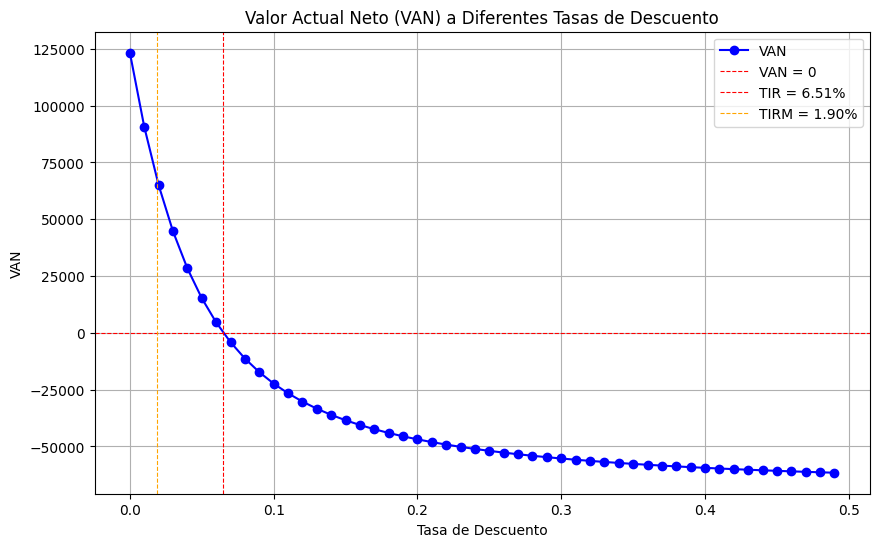

In [32]:
# --- Calcular TIR y TIRM ---
flujos = nuevo_cash_flow.copy()
# tir = nf.irr(flujos)
# tirm = nf.mirr(flujos, rfinanciamiento, rreinversion)

print(f"Tasa Interna de Retorno (TIR): {tir:.2%}")
print(f"Tasa Interna de Retorno Modificada (TIRM): {tirm:.2%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.5), 0.01) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VAN')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='VAN = 0')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='red', linestyle='--', linewidth=0.8, label=f"TIR = {tir:.2%}")
plt.axvline(tirm, color='orange', linestyle='--', linewidth=0.8, label=f"TIRM = {tirm:.2%}")

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.legend()
plt.show()


### 1.3 Nuevo costo

In [33]:
r2 = 0.21 / 12  # Convertir tasa anual a mensual
van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)
tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=r2, reinvest_rate=r2)
prd2 = payback_desc(cash_flows, r2, inversion_inicial)

In [34]:
print(f"VAN con nueva tasa de descuento ({r2:.2%}): {van2:.2f}")
print(f"TIR con nueva tasa de descuento: {tir2:.2%}")
print(f"TIRM con nueva tasa de descuento: {tirm2:.2%}")
print(f"Payback descontado con nueva tasa de descuento: {prd2:.2f} meses")

VAN con nueva tasa de descuento (1.75%): 70878.54
TIR con nueva tasa de descuento: 6.51%
TIRM con nueva tasa de descuento: 2.70%
Payback descontado con nueva tasa de descuento: 20.87 meses


In [35]:
# Crear cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'Payback Desc.'],
    'K0 9% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    'K0 21% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))

# Interpretación adicional
print("\n" + "=" * 60)
print("INTERPRETACIÓN COMPARATIVA:")
print(f"\n• VAN: Disminuye ${van - van2:,.2f} al aumentar el costo de capital del 9% al 21%.")
print(f"  Con K=21%, el proyecto {'NO es viable (VAN < 0)' if van2 < 0 else 'sigue siendo viable (VAN > 0)'}.")

print(f"\n• TIR: Se mantiene constante en {tir_anual:.2%} (característica intrínseca del proyecto).")
print(f"  La TIR no depende del costo de capital, solo de los flujos del proyecto.")

print(f"\n• TIRM: {'Aumenta' if tirm2 > tirm else 'Disminuye'} de {tirm_anual:.2%} a {(1 + tirm2)**12 - 1:.2%}.")
print(f"  Este proyecto tiene {sum(1 for fc in cash_flows if fc < 0)} flujos negativos intermedios.")
print(f"  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,")
print(f"  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.")

print(f"  donde el impacto del descuento es aún moderado.")

print(f"\n• Payback: Aumenta de {prd:.2f} a {prd2:.2f} meses (+{prd2-prd:.2f} meses).")
print(f"  La recuperación es similar en ambos casos porque ocurre temprano (meses 3-4),")

CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
      Métrica K0 9% anual K0 21% anual Diferencia
          VAN  $98,116.48   $70,878.54 $27,237.94
          TIR       6.51%        6.51% Sin cambio
         TIRM       1.90%        2.70%      0.80%
Payback Desc. 20.62 meses  20.87 meses 0.25 meses

INTERPRETACIÓN COMPARATIVA:

• VAN: Disminuye $27,237.94 al aumentar el costo de capital del 9% al 21%.
  Con K=21%, el proyecto sigue siendo viable (VAN > 0).

• TIR: Se mantiene constante en 113.05% (característica intrínseca del proyecto).
  La TIR no depende del costo de capital, solo de los flujos del proyecto.

• TIRM: Aumenta de 25.35% a 37.74%.
  Este proyecto tiene 12 flujos negativos intermedios.
  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,
  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.
  donde el impacto del descuento es aún moderado.

• Payback: Aumenta de 20.62 a 20.87 meses (+0.25 meses).
  La recuperac

### 1.4 Gráficos Comparativos

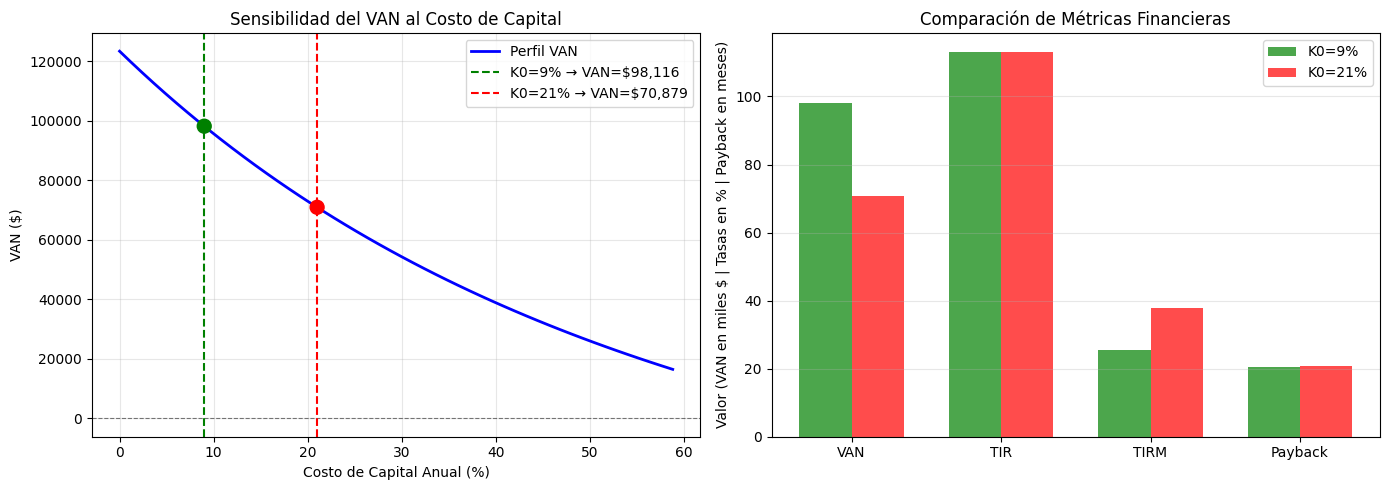


📊 ANÁLISIS GRÁFICO:
• Gráfico izquierdo: Muestra cómo el VAN disminuye al aumentar el costo de capital.
  La pendiente negativa indica que el proyecto es sensible al costo de financiamiento.
• Gráfico derecho: Compara las 4 métricas bajo ambos escenarios de costo de capital.
  Note que TIR no cambia (es independiente del costo de capital).


In [36]:
# Gráfico 1: Comparación de VAN a diferentes tasas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: VAN vs Tasa de Descuento (ambos escenarios)
tasas_rango = np.arange(0, 0.05, 0.001)  # Tasas mensuales de 0% a 5%
van_por_tasa_completo = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

ax1.plot(tasas_rango * 12 * 100, van_por_tasa_completo, color='blue', linewidth=2, label='Perfil VAN')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(r * 12 * 100, color='green', linestyle='--', linewidth=1.5, label=f'K0=9% → VAN=${van:,.0f}')
ax1.axvline(r2 * 12 * 100, color='red', linestyle='--', linewidth=1.5, label=f'K0=21% → VAN=${van2:,.0f}')
ax1.scatter([r * 12 * 100, r2 * 12 * 100], [van, van2], color=['green', 'red'], s=100, zorder=5)

ax1.set_xlabel('Costo de Capital Anual (%)')
ax1.set_ylabel('VAN ($)')
ax1.set_title('Sensibilidad del VAN al Costo de Capital')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Panel derecho: Comparación de métricas
metricas = ['VAN', 'TIR', 'TIRM', 'Payback']
valores_9 = [van, (1 + tir)**12 - 1, (1 + tirm)**12 - 1, prd]
valores_21 = [van2, (1 + tir2)**12 - 1, (1 + tirm2)**12 - 1, prd2]

x_pos = np.arange(len(metricas))
width = 0.35

ax2.bar(x_pos - width/2, [valores_9[0]/1000, valores_9[1]*100, valores_9[2]*100, valores_9[3]], 
        width, label='K0=9%', color='green', alpha=0.7)
ax2.bar(x_pos + width/2, [valores_21[0]/1000, valores_21[1]*100, valores_21[2]*100, valores_21[3]], 
        width, label='K0=21%', color='red', alpha=0.7)

ax2.set_ylabel('Valor (VAN en miles $ | Tasas en % | Payback en meses)')
ax2.set_title('Comparación de Métricas Financieras')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metricas)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 ANÁLISIS GRÁFICO:")
print(f"• Gráfico izquierdo: Muestra cómo el VAN disminuye al aumentar el costo de capital.")
print(f"  La pendiente negativa indica que el proyecto es sensible al costo de financiamiento.")
print(f"• Gráfico derecho: Compara las 4 métricas bajo ambos escenarios de costo de capital.")
print(f"  Note que TIR no cambia (es independiente del costo de capital).")

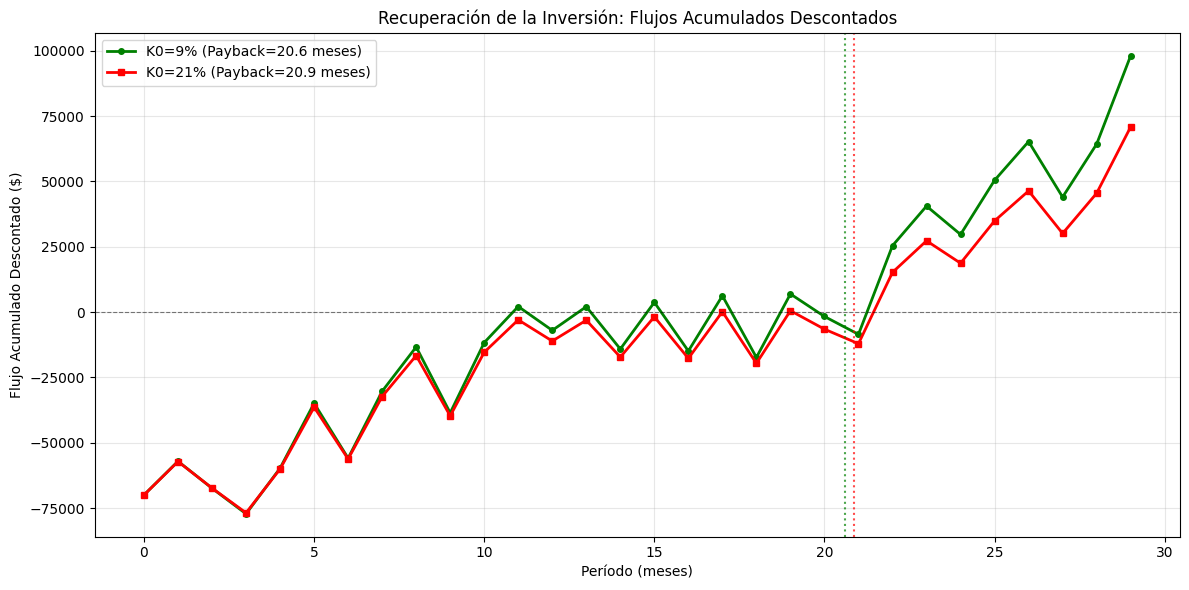


📊 ANÁLISIS DEL PAYBACK:
• Las líneas cruzan el eje horizontal (flujo acumulado = 0) en el momento de recuperación.
• Con mayor tasa de descuento (21%), los flujos valen menos → recuperación más lenta (+0.3 meses).
• Ambos períodos son similares porque la recuperación ocurre temprano (meses 3-4),
  donde el efecto acumulado del descuento aún es pequeño.


In [37]:
# Gráfico 2: Flujos de caja acumulados descontados
fig, ax = plt.subplots(figsize=(12, 6))

# Calcular flujos acumulados descontados para ambas tasas
periodos = np.arange(0, len(nuevo_cash_flow))
flujos_desc_acum_9 = []
flujos_desc_acum_21 = []
acum_9 = 0
acum_21 = 0

for t, fc in enumerate(nuevo_cash_flow):
    fc_desc_9 = fc / (1 + r)**t
    fc_desc_21 = fc / (1 + r2)**t
    acum_9 += fc_desc_9
    acum_21 += fc_desc_21
    flujos_desc_acum_9.append(acum_9)
    flujos_desc_acum_21.append(acum_21)

ax.plot(periodos, flujos_desc_acum_9, marker='o', color='green', linewidth=2, 
        label=f'K0=9% (Payback={prd:.1f} meses)', markersize=4)
ax.plot(periodos, flujos_desc_acum_21, marker='s', color='red', linewidth=2, 
        label=f'K0=21% (Payback={prd2:.1f} meses)', markersize=4)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(prd, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(prd2, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Período (meses)')
ax.set_ylabel('Flujo Acumulado Descontado ($)')
ax.set_title('Recuperación de la Inversión: Flujos Acumulados Descontados')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 ANÁLISIS DEL PAYBACK:")
print(f"• Las líneas cruzan el eje horizontal (flujo acumulado = 0) en el momento de recuperación.")
print(f"• Con mayor tasa de descuento (21%), los flujos valen menos → recuperación más lenta (+{prd2-prd:.1f} meses).")
print(f"• Ambos períodos son similares porque la recuperación ocurre temprano (meses 3-4),")
print(f"  donde el efecto acumulado del descuento aún es pequeño.")

#### Análisis de Riesgo con Simulación Monte Carlo

La simulación Monte Carlo permite evaluar el riesgo del proyecto considerando:
- **Volatilidad en flujos de caja**: Los flujos pueden variar por incertidumbre de mercado
- **Volatilidad en tasa de descuento**: La tasa puede cambiar por condiciones económicas

Se realizan 1,000 simulaciones para obtener una distribución de resultados posibles del VAN.

In [38]:
# Importar funciones de Monte Carlo desde utils
import sys
sys.path.append('/home/alexballera/Documents/uba/laboratorio-tgad-fce/utils')
from matematicas_financieras import monte_carlo_npv, plot_monte_carlo_results

In [39]:
# Parámetros de la simulación
discount_rate_mean = r  # Tasa de descuento promedio (0.75% mensual = 9% anual)
volatility_flows = 0.40  # 40% de volatilidad en flujos de caja
volatility_rate = 0.10  # 10% de volatilidad en la tasa de descuento
simulations = 1000

print("PARÁMETROS DE SIMULACIÓN MONTE CARLO")
print("=" * 50)
print(f"• Tasa de descuento promedio: {discount_rate_mean:.4%} mensual ({discount_rate_mean*12:.2%} anual)")
print(f"• Volatilidad de flujos: ±{volatility_flows:.1%}")
print(f"• Volatilidad de tasa: ±{volatility_rate:.3%} mensual (±{volatility_rate*12:.2%} anual)")
print(f"• Número de simulaciones: {simulations:,}")
print()

PARÁMETROS DE SIMULACIÓN MONTE CARLO
• Tasa de descuento promedio: 0.7500% mensual (9.00% anual)
• Volatilidad de flujos: ±40.0%
• Volatilidad de tasa: ±10.000% mensual (±120.00% anual)
• Número de simulaciones: 1,000



In [40]:
# Ejecutar simulación Monte Carlo
resultados_mc = monte_carlo_npv(
    cash_flows=nuevo_cash_flow,
    discount_rate_mean=discount_rate_mean,
    volatility_flows=volatility_flows,
    volatility_rate=volatility_rate,
    simulations=simulations
)

print("✅ Simulación completada")

✅ Simulación completada


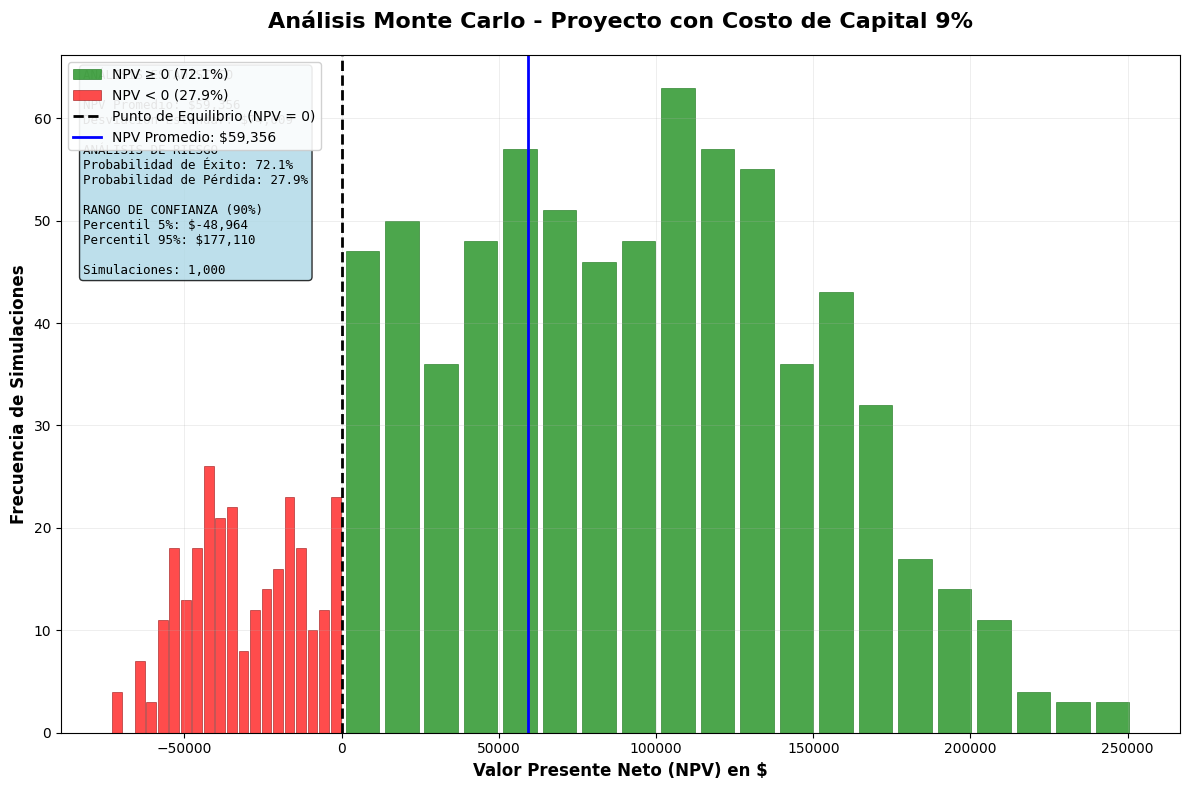

In [41]:
# Visualizar resultados con gráfico profesional (con barras más angostas)
metricas_mc = plot_monte_carlo_results(
    resultados_mc, 
    "Análisis Monte Carlo - Proyecto con Costo de Capital 9%"
)

In [42]:
# Análisis e interpretación de resultados Monte Carlo
print("\n" + "="*70)
print("INTERPRETACIÓN DEL ANÁLISIS MONTE CARLO")
print("="*70)

# Comparación con VAN determinístico
print(f"\n📊 Comparación VAN Determinístico vs Monte Carlo:")
print(f"   • VAN determinístico: ${van:,.2f}")
print(f"   • VAN promedio (MC): ${metricas_mc['npv_mean']:,.2f}")
print(f"   • Diferencia: ${metricas_mc['npv_mean'] - van:,.2f}")

# Análisis de riesgo
print(f"\n⚠️ Análisis de Riesgo:")
print(f"   • Desviación estándar: ${metricas_mc['npv_std']:,.2f}")
print(f"   • Coeficiente de variación: {metricas_mc['npv_std']/abs(metricas_mc['npv_mean']):.2%}")
print(f"   • Probabilidad de éxito (VAN ≥ 0): {metricas_mc['success_probability']:.1%}")
print(f"   • Probabilidad de pérdida (VAN < 0): {metricas_mc['failure_probability']:.1%}")

# Rango de confianza
print(f"\n📈 Rango de Confianza (90%):")
print(f"   • Escenario pesimista (P5): ${metricas_mc['percentile_5']:,.2f}")
print(f"   • Escenario optimista (P95): ${metricas_mc['percentile_95']:,.2f}")
print(f"   • Amplitud del rango: ${metricas_mc['percentile_95'] - metricas_mc['percentile_5']:,.2f}")

# Decisión final
print(f"\n🎯 DECISIÓN:")
if metricas_mc['npv_mean'] > 0 and metricas_mc['success_probability'] > 0.70:
    decision = "✅ ACEPTAR EL PROYECTO"
    justificacion = f"VAN promedio positivo con {metricas_mc['success_probability']:.1%} probabilidad de éxito"
elif metricas_mc['npv_mean'] > 0:
    decision = "⚠️ ANALIZAR MÁS DETALLADAMENTE"
    justificacion = "VAN positivo pero con riesgo significativo"
else:
    decision = "❌ RECHAZAR EL PROYECTO"
    justificacion = "VAN promedio negativo indica destrucción de valor"

print(f"   {decision}")
print(f"   Justificación: {justificacion}")

print("\n" + "="*70)


INTERPRETACIÓN DEL ANÁLISIS MONTE CARLO

📊 Comparación VAN Determinístico vs Monte Carlo:
   • VAN determinístico: $98,116.48
   • VAN promedio (MC): $59,355.92
   • Diferencia: $-38,760.56

⚠️ Análisis de Riesgo:
   • Desviación estándar: $74,008.81
   • Coeficiente de variación: 124.69%
   • Probabilidad de éxito (VAN ≥ 0): 72.1%
   • Probabilidad de pérdida (VAN < 0): 27.9%

📈 Rango de Confianza (90%):
   • Escenario pesimista (P5): $-48,964.25
   • Escenario optimista (P95): $177,110.21
   • Amplitud del rango: $226,074.46

🎯 DECISIÓN:
   ✅ ACEPTAR EL PROYECTO
   Justificación: VAN promedio positivo con 72.1% probabilidad de éxito

